In [ ]:
# Mathematical models related to diffusion
# First we will take an image from Dataset
# Observe the noising step (beta which decides the rate of noising) of this image
# Denoise the same image (train our model)
# Trained model to decipher a sanskrit manuscript (diffusers library)

In [ ]:
# Mathematical models related to diffusion

# Forward diffusion equation
# x(t) = (sqrt)(1-beta)x(t-1) + sqrt(beta*epsilon)

# x(t) = Noisy image
# epsilon = Gaussian noise
# beta = noise schedule

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt



In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

 13%|█▎        | 22.3M/170M [07:49<40:14, 61.4kB/s]

In [ ]:
# Select a fixed image

image_index = 0
x0, label = dataset[image_index]

print("Class label:", dataset.classes[label])


Class label: frog


In [ ]:
def add_noise(x, beta):
  noise = torch.randn_like(x)
  return torch.sqrt(1-beta)*x + torch.sqrt(beta)*noise

In [ ]:
# Reverse Process

#Instead of directly predicting original image, it predicts
# epsilon(xt, t)

# Why?
# Predicting noise is easier than predicting image

# U-net backbone
# Time embedding
# Noise Scheduler

In [ ]:
betas = [0.01, 0.05, 0.1, 0.3, 0.6]

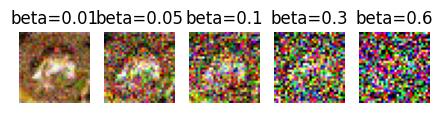

In [ ]:
for i,b in enumerate(betas):
  xt = add_noise(x0, torch.tensor(b))
  plt.subplot(1, len(betas)+1, i+2)
  plt.imshow(xt.permute(1,2,0).clamp(0,1))
  plt.title(f"beta={b}")
  plt.axis("off")

plt.show()

# More beta (noise scheduling parameter) => more destruction

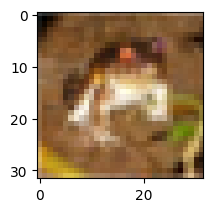

In [ ]:
plt.figure(figsize=(15,3))

plt.subplot(1, len(betas)+1, 1)
plt.imshow(x0.permute(1,2,0))

In [ ]:
# Apply pretrained diffusion model

from diffusers import StableDiffusionPipeline
import torch
print("Is available :: ",torch.cuda.is_available())
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

prompt = "English alphabet"
image = pipe(prompt).images[0]
plt.imshow(image)
plt.axis("off")
plt.show()
image.save("output.png")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Is available ::  True


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

NameError: name 'plt' is not defined

In [ ]:
from PIL import Image

img = Image.open("output.png")
img.show()

Is available ::  True


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

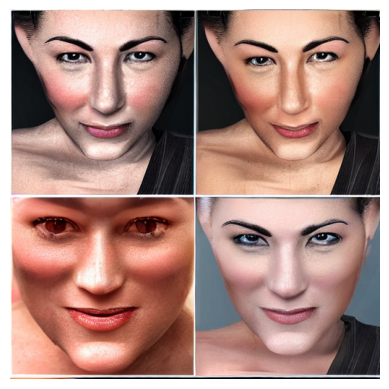

In [ ]:
# Image-to-Image Generation


from diffusers import StableDiffusionPipeline
import torch
print("Is available :: ",torch.cuda.is_available())
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

init_image = Image.open("edited.png")

prompt = "Can you increase the resolution, sharpen facial features"
image = pipe(prompt=prompt, image=init_image, strength=0.7).images[0]
plt.imshow(image)
plt.axis("off")
plt.show()
image.save("edited_2.png")

# Strength parameter controls how much noise is added
# More noise  ====> more creativity
# Less noise ===> More structure preservation

## Extension Exercise: Understanding Forward Diffusion Over Timesteps

In a full diffusion model, noise isn't added in a single step with a fixed `beta`. Instead, it's a gradual process over many small steps, known as timesteps (`T`), each with its own `beta` value. The collection of `beta` values for each timestep is called the noise schedule.

This exercise will help visualize how an image progressively becomes pure noise as we apply the forward diffusion process over several timesteps, using a simple linear noise schedule.

In [ ]:
import numpy as np

# Define the number of timesteps
T = 1000

# Define a linear noise schedule
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T)

# Calculate alpha values (1 - beta)
alphas = 1.0 - betas

# Calculate cumulative product of alphas
alpha_cumprod = torch.cumprod(alphas, axis=0)

print(f"Number of timesteps (T): {T}")
print(f"First 5 betas: {betas[:5]}")
print(f"Last 5 betas: {betas[-5:]}")

Now, let's observe the image at a few selected timesteps to see how it gradually transforms into noise. We'll reuse the `add_noise` function, but apply the formula for `x_t` directly, which incorporates the cumulative product of alphas for efficient computation over many steps:

`x_t = sqrt(alpha_cumprod_t) * x_0 + sqrt(1 - alpha_cumprod_t) * epsilon`

In [ ]:
def forward_diffusion_at_t(x0, t, alpha_cumprod):
  """Applies forward diffusion to x0 at a specific timestep t."""
  noise = torch.randn_like(x0)
  sqrt_alpha_cumprod_t = torch.sqrt(alpha_cumprod[t-1]) # t-1 because alpha_cumprod is 0-indexed
  sqrt_one_minus_alpha_cumprod_t = torch.sqrt(1.0 - alpha_cumprod[t-1])
  xt = sqrt_alpha_cumprod_t * x0 + sqrt_one_minus_alpha_cumprod_t * noise
  return xt

# Choose a few timesteps to visualize
visualization_timesteps = [1, 50, 100, 200, 500, 999]

plt.figure(figsize=(15, 4))
plt.subplot(1, len(visualization_timesteps) + 1, 1)
plt.imshow(x0.permute(1, 2, 0).clamp(0, 1)) # Original image
plt.title("Original x0")
plt.axis("off")

for i, t in enumerate(visualization_timesteps):
  xt = forward_diffusion_at_t(x0, t, alpha_cumprod)
  plt.subplot(1, len(visualization_timesteps) + 1, i + 2)
  plt.imshow(xt.permute(1, 2, 0).clamp(0, 1))
  plt.title(f"t={t}")
  plt.axis("off")

plt.tight_layout()
plt.show()

As you can see, as the timestep `t` increases, more noise is added, and the original image progressively becomes indistinguishable from pure Gaussian noise. This is the forward process that a diffusion model aims to reverse during denoising.

In [ ]:
# Difference between DDPM vs DDIM
# DDPM = Probabilistic Denoising model (stochastic) 1000 -> 995 -> 985 -> 965 -> 930 ->.....->0
# DDIM = Implicit Denoising model (deterministic) 1000 -> 800 -> 600 -> 400 -> 200 -> ....->0
#Sampling procedure is different